# 📊 Student Performance AI

# Notebook 02 — Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to explore the dataset visually and statistically before preprocessing and model development.

## Learning Objectives

- Understand feature distributions
- Analyze the target variable
- Detect outliers
- Study feature relationships
- Identify important variables
- Generate insights for preprocessing

---

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

pd.set_option('display.max_columns', None)
print("libraries are loaded succesfullly!")



libraries are loaded succesfullly!


In [2]:
# load the datset
DATA_PATH = "../data/raw/student-performance.csv"
df = pd.read_csv(DATA_PATH, sep=';')
df.head()
print("datset is loaded succesfully!")

datset is loaded succesfully!


# Dataset Overview

Before visualization, let's quickly review the dataset.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

# Target Variable Analysis

The target variable for this project is **G3**, representing the student's final grade.

Understanding its distribution helps determine whether the prediction task is balanced and whether transformations may be required.

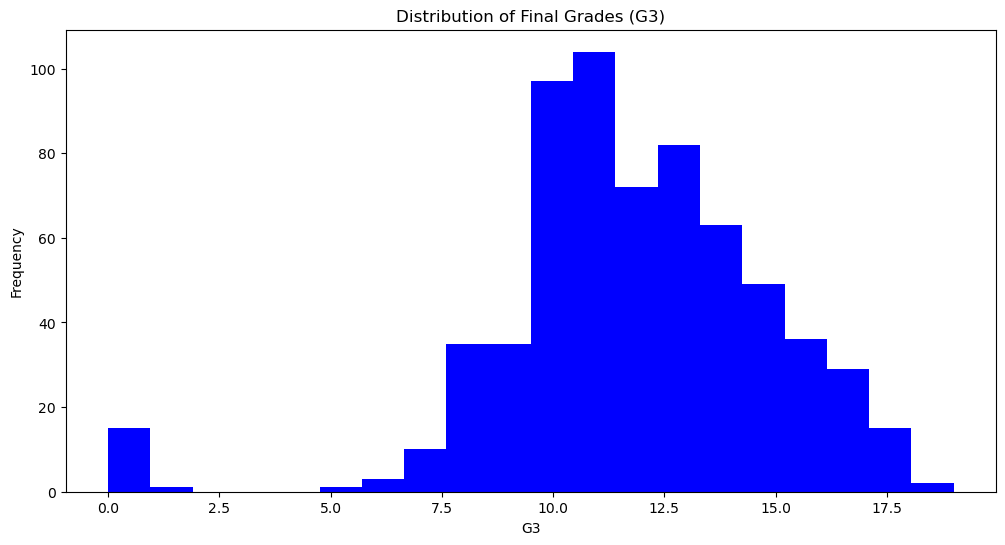

In [4]:
plt.figure(figsize=(12, 6))
plt.hist(df["G3"], bins=20,color='blue' )
plt.xlabel("G3")
plt.ylabel("Frequency")
plt.title("Distribution of Final Grades (G3)")
plt.show()


### Observation

- Most students scored between the middle grade ranges.
- Very low and very high grades are less frequent.
- The target distribution appears suitable for a regression problem.

# Numerical Features Distribution

Understanding numerical features helps identify:

- skewness
- unusual values
- feature ranges

In [5]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='str')

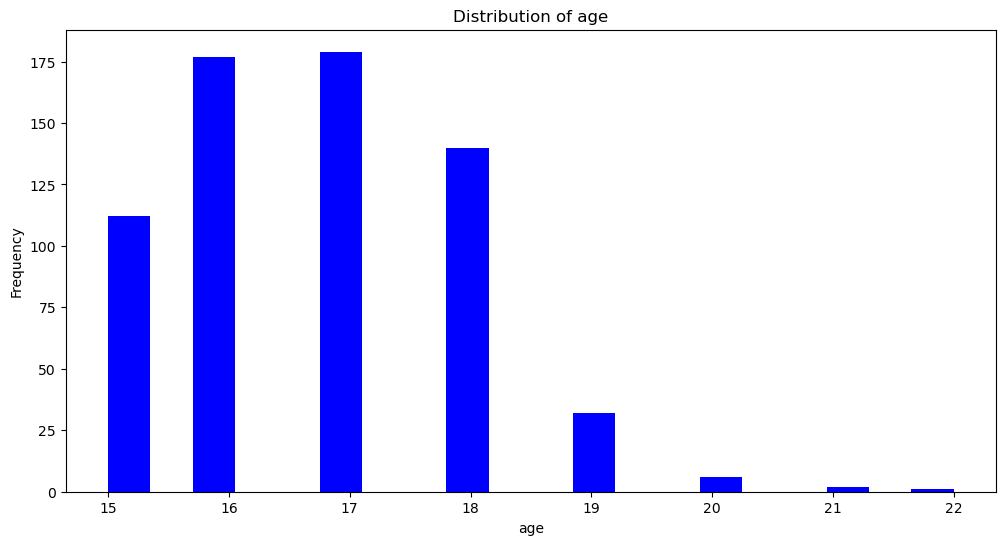

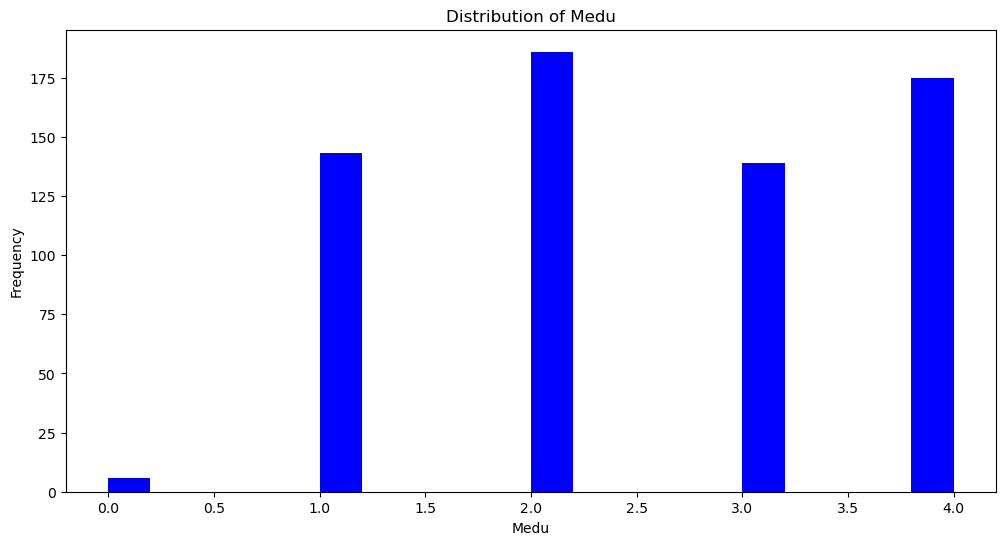

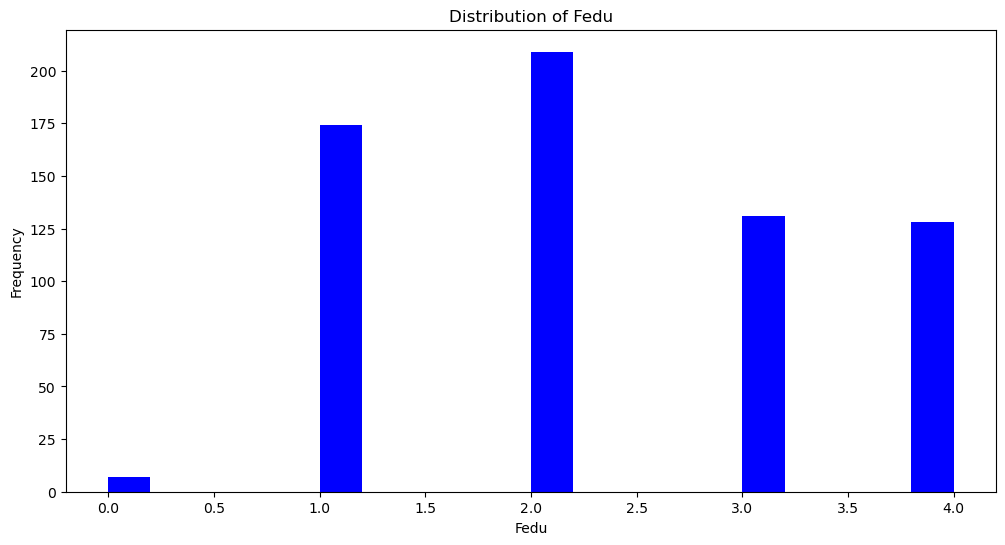

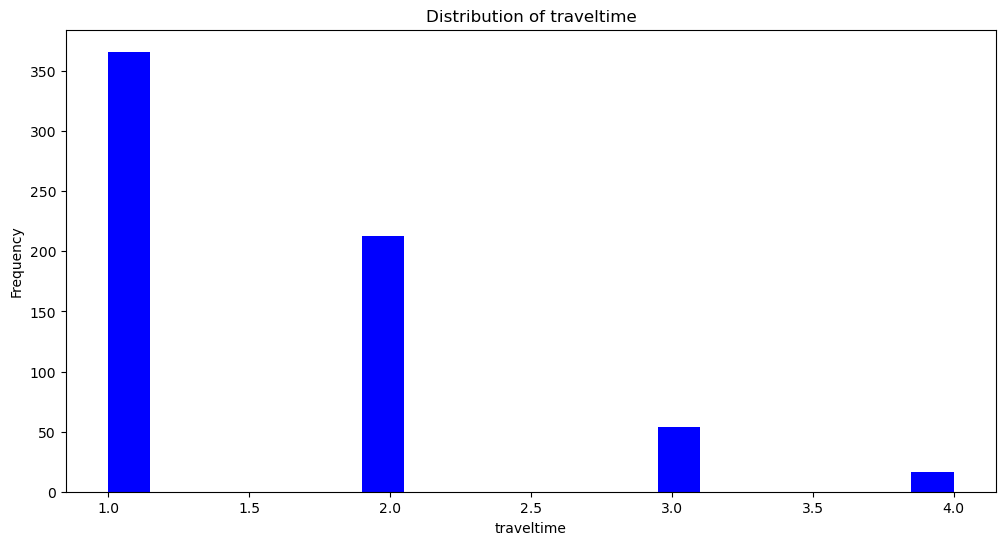

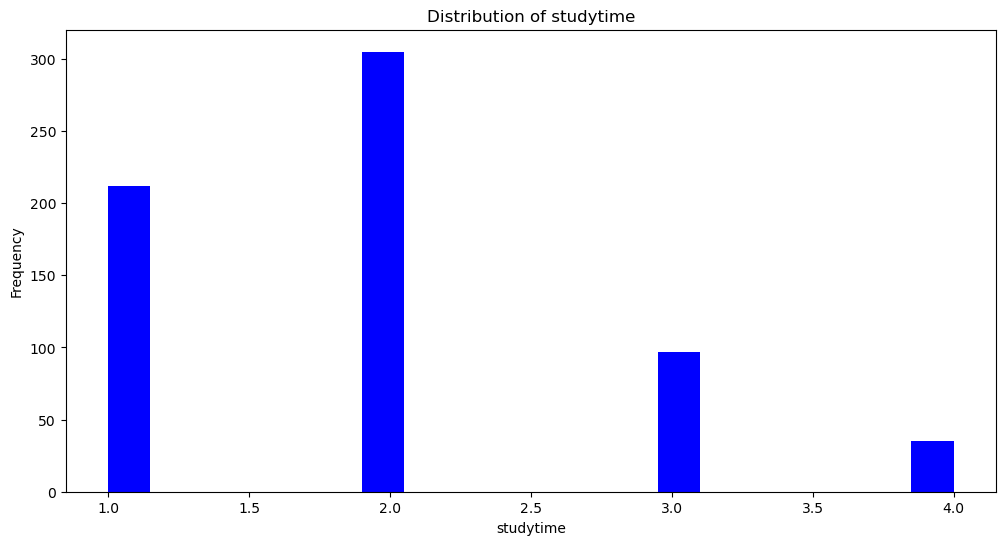

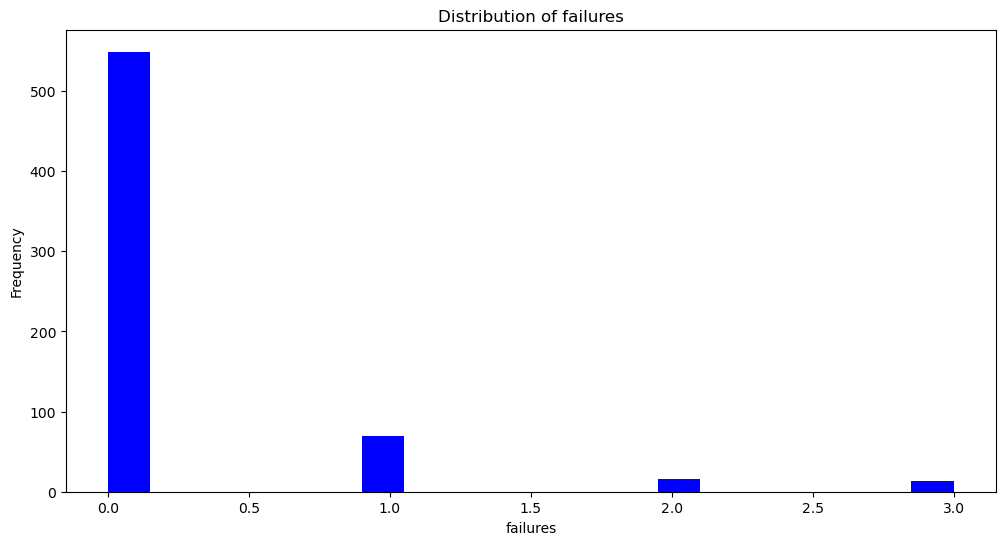

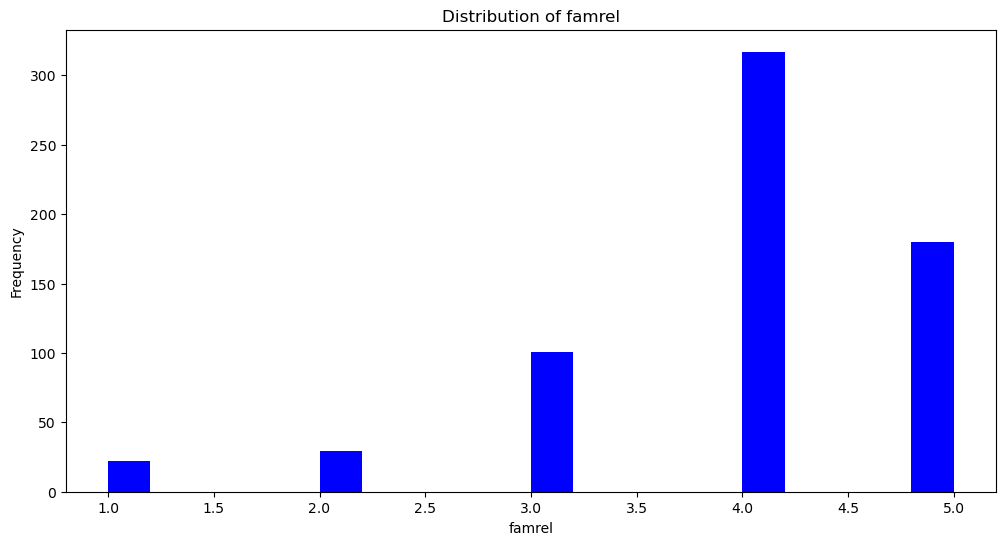

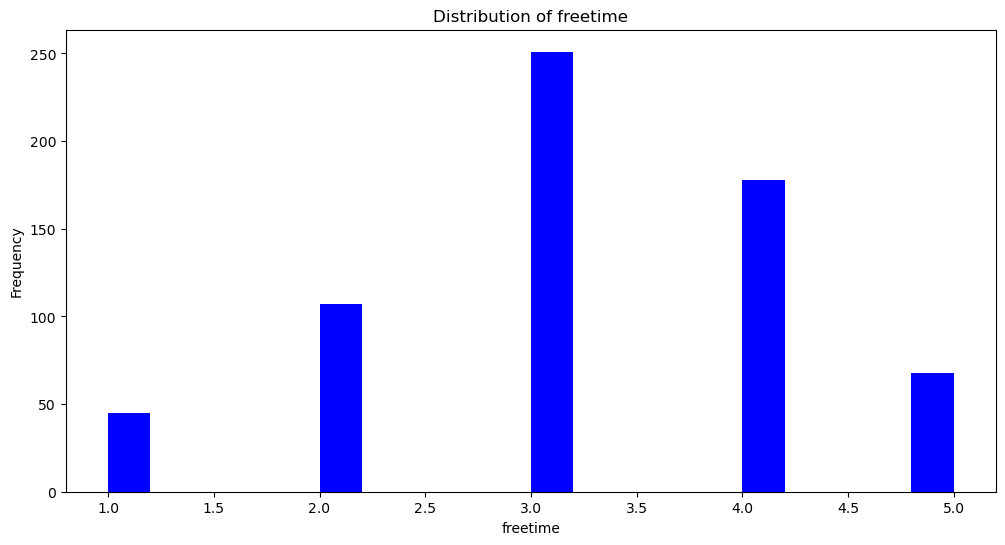

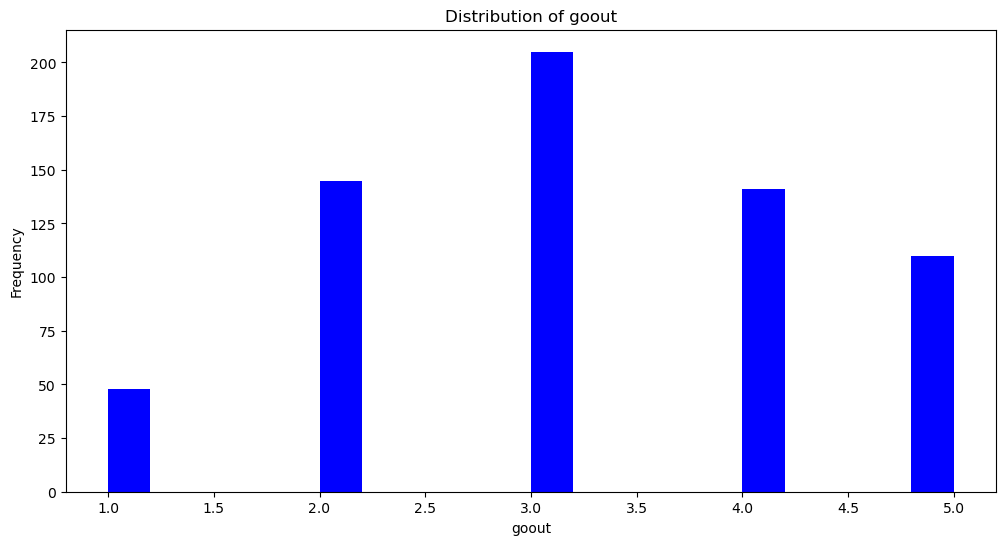

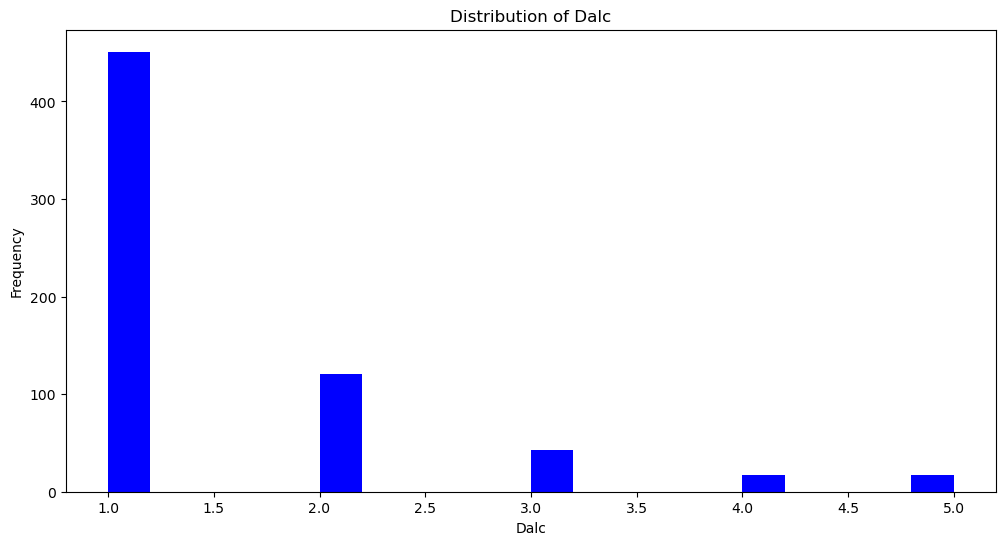

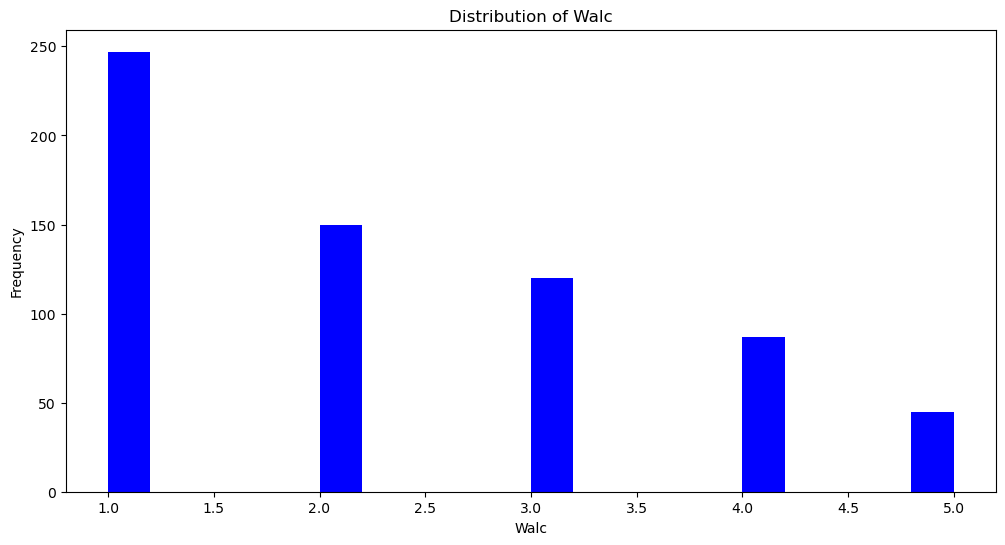

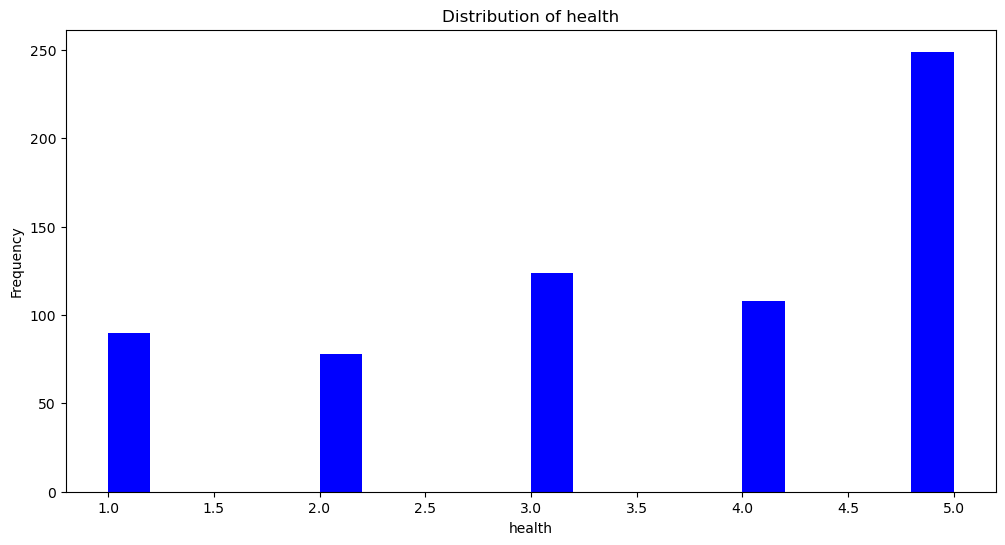

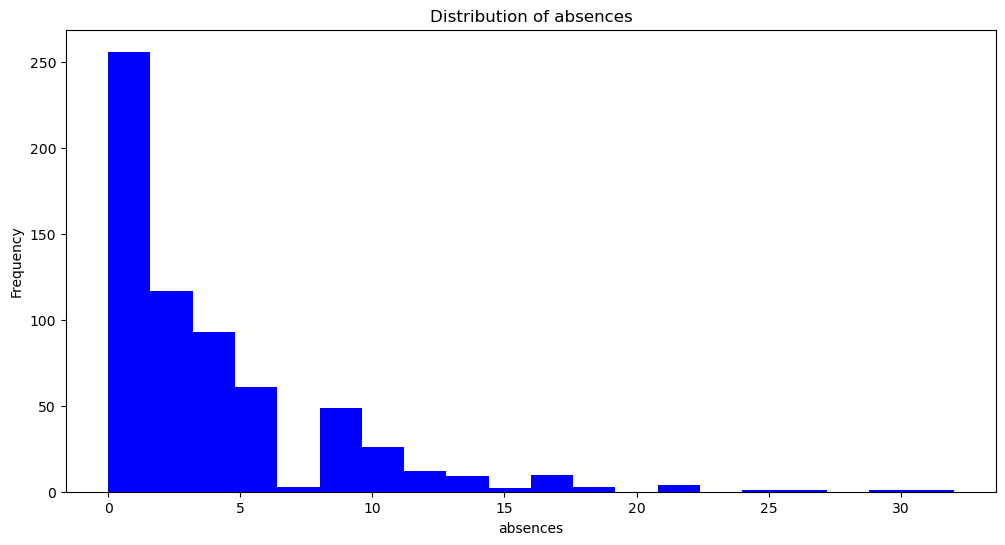

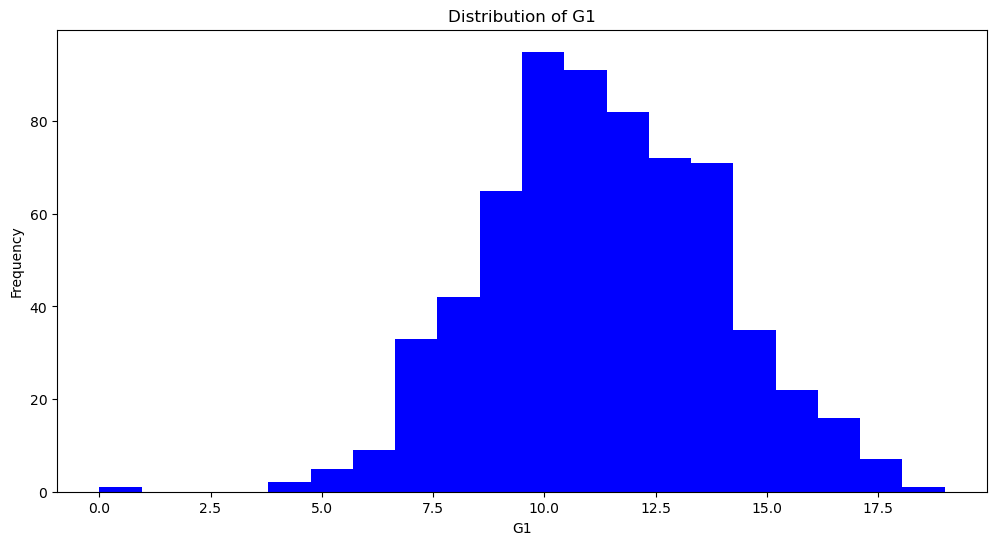

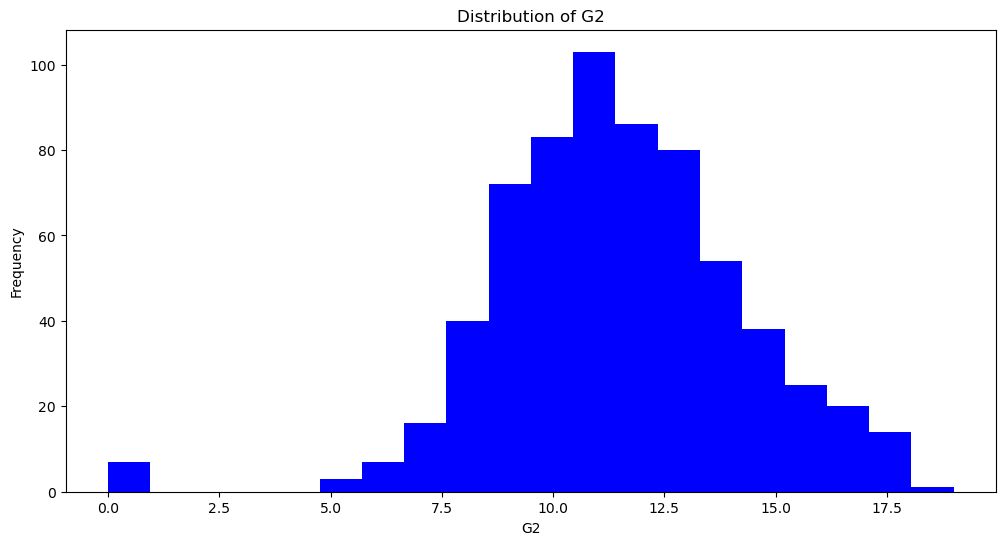

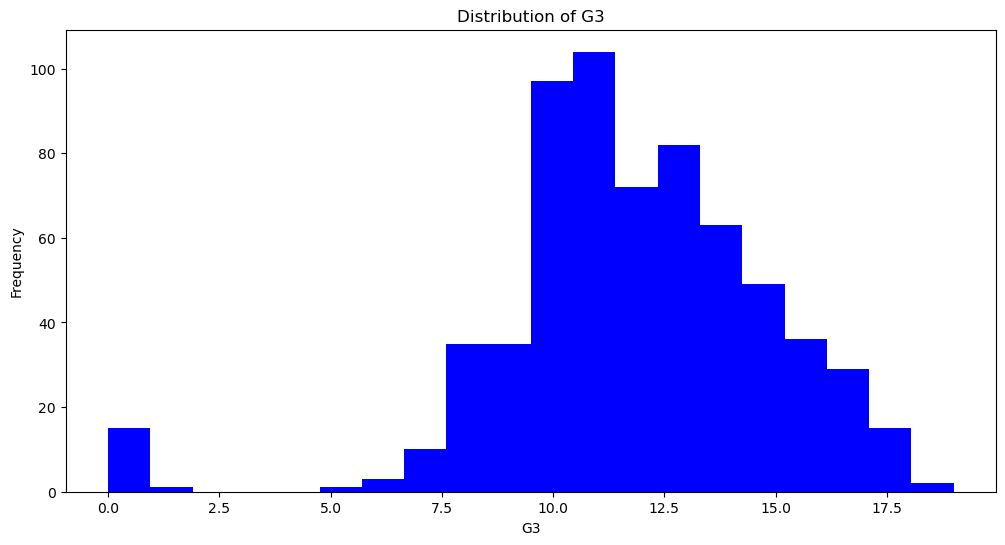

In [6]:
for col in numerical_cols:
    plt.figure(figsize=(12, 6))
    plt.hist(df[col], bins=20, color='blue')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

# Categorical Feature Analysis

Let's inspect how categorical variables are distributed.

In [7]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

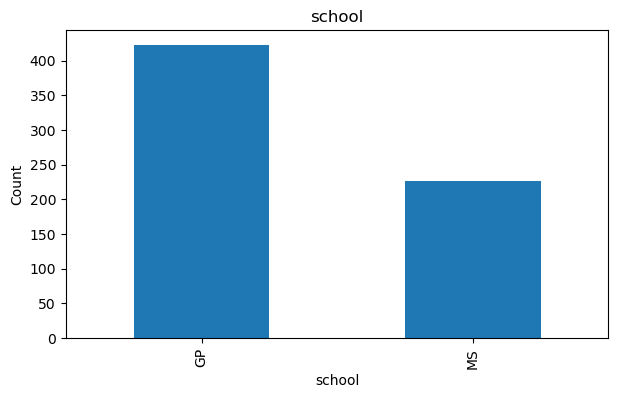

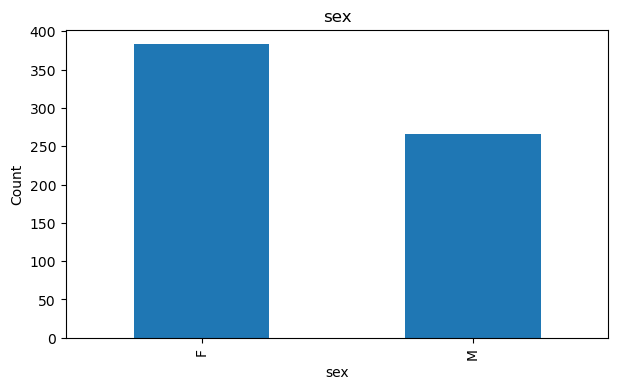

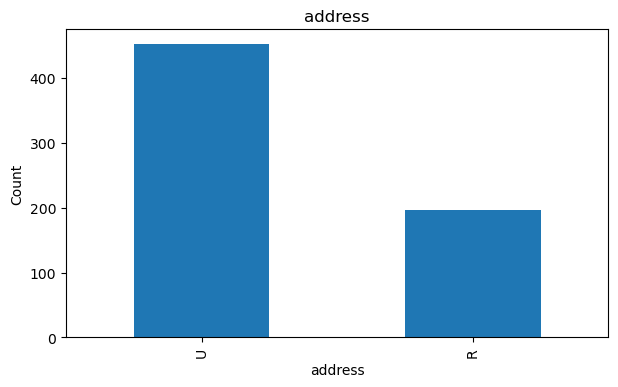

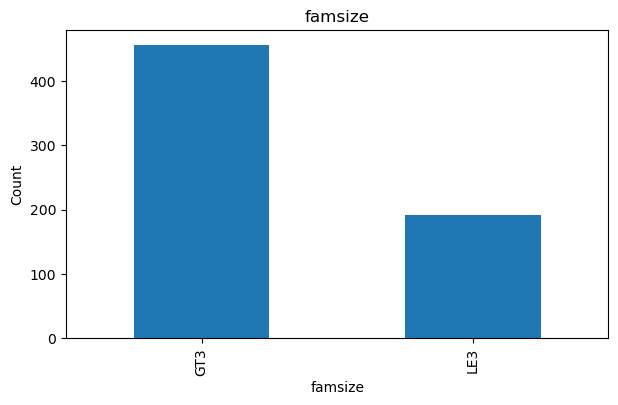

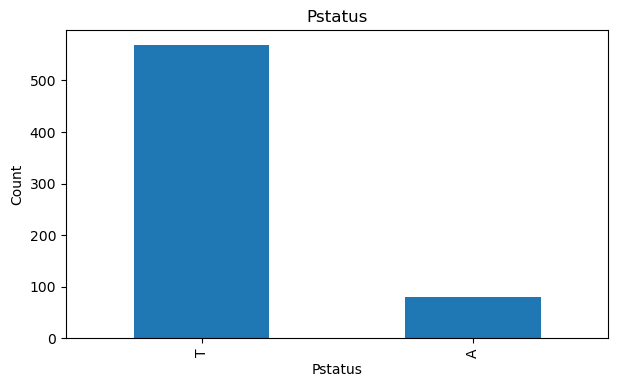

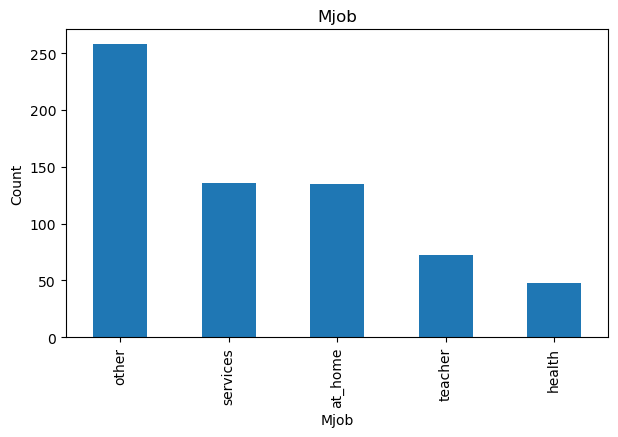

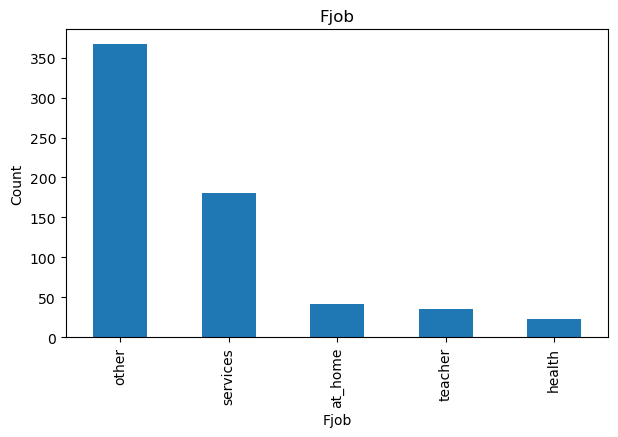

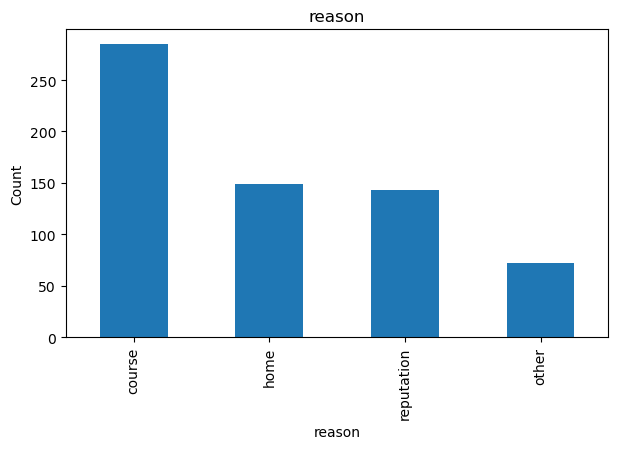

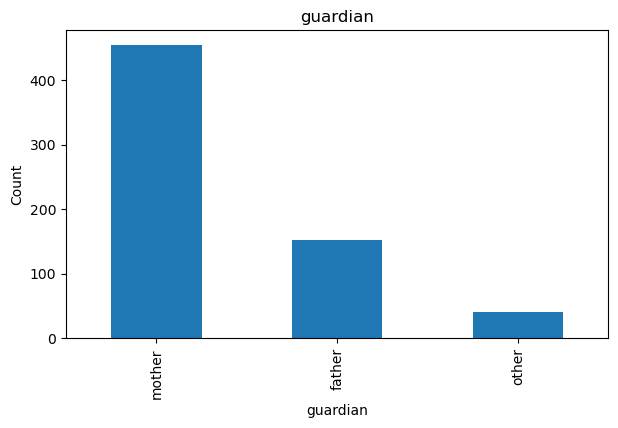

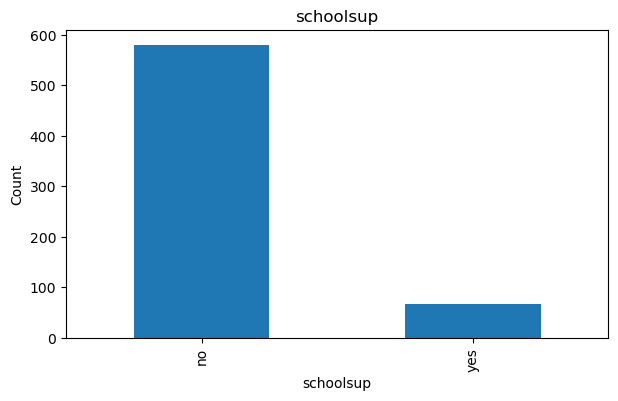

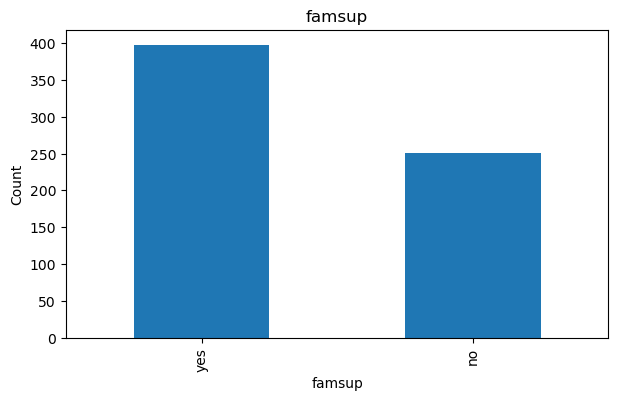

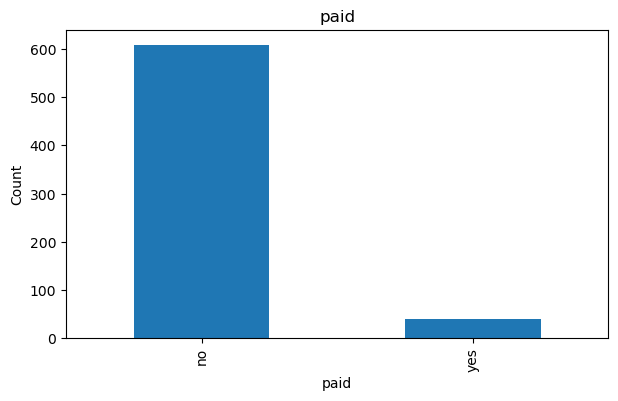

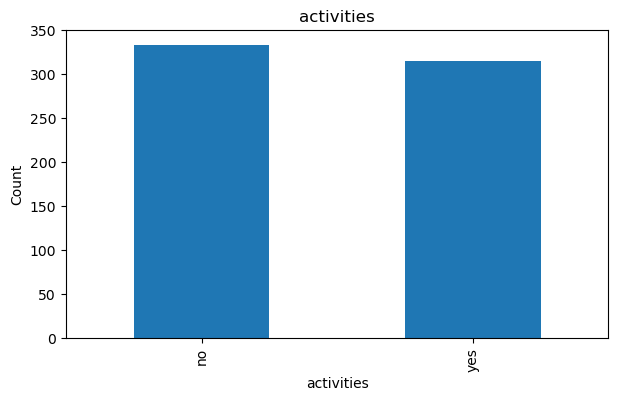

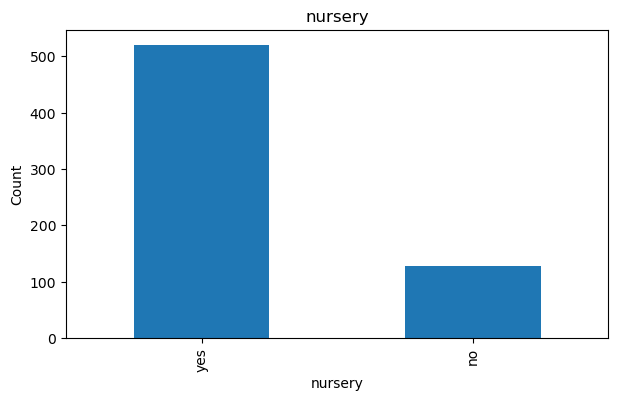

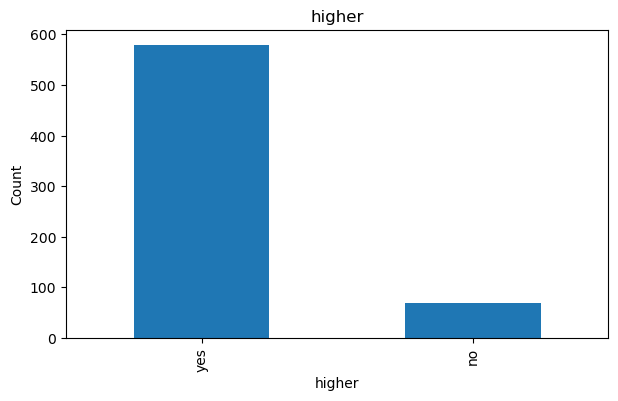

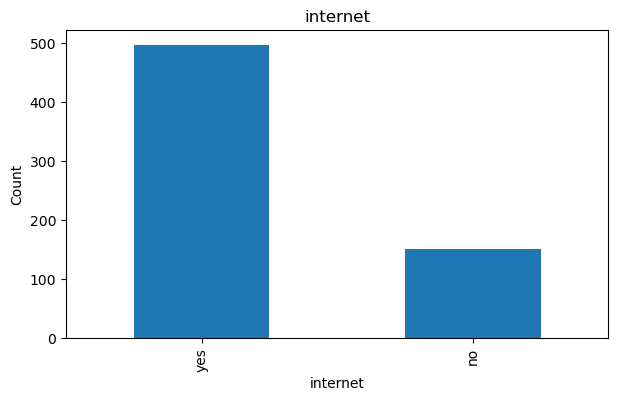

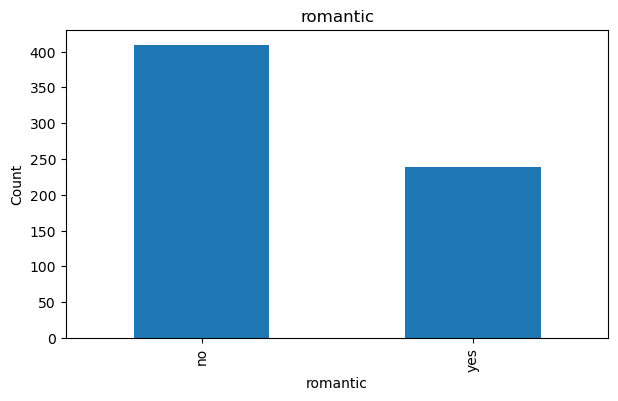

In [8]:
for column in categorical_columns:

    plt.figure(figsize=(7,4))

    df[column].value_counts().plot(kind="bar")

    plt.title(column)

    plt.ylabel("Count")

    plt.show()

### Observation

Check whether categories are balanced or highly imbalanced.

Highly imbalanced features should be noted before encoding.

# Correlation Analysis

Correlation measures the strength of linear relationships between numerical variables.

This helps identify which features are most associated with the target variable.

In [10]:
correlation = df[numerical_cols].corr()

correlation

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.107832,-0.121050,0.034490,-0.008415,0.319968,-0.020559,-0.004910,0.112805,0.134768,0.086357,-0.008750,0.149998,-0.174322,-0.107119,-0.106505
Medu,-0.107832,1.000000,0.647477,-0.265079,0.097006,-0.172210,0.024421,-0.019686,0.009536,-0.007018,-0.019766,0.004614,-0.008577,0.260472,0.264035,0.240151
Fedu,-0.121050,0.647477,1.000000,-0.208288,0.050400,-0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859,0.217501,0.225139,0.211800
traveltime,0.034490,-0.265079,-0.208288,1.000000,-0.063154,0.097730,-0.009521,0.000937,0.057454,0.092824,0.057007,-0.048261,-0.008149,-0.154120,-0.154489,-0.127173
studytime,-0.008415,0.097006,0.050400,-0.063154,1.000000,-0.147441,-0.004127,-0.068829,-0.075442,-0.137585,-0.214925,-0.056433,-0.118389,0.260875,0.240498,0.249789
failures,0.319968,-0.172210,-0.165915,0.097730,-0.147441,1.000000,-0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779,-0.384210,-0.385782,-0.393316
famrel,-0.020559,0.024421,0.020256,-0.009521,-0.004127,-0.062645,1.000000,0.129216,0.089707,-0.075767,-0.093511,0.109559,-0.089534,0.048795,0.089588,0.063361
freetime,-0.004910,-0.019686,0.006841,0.000937,-0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,-0.018716,-0.094497,-0.106678,-0.122705
goout,0.112805,0.009536,0.027690,0.057454,-0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,-0.015741,0.085374,-0.074053,-0.079469,-0.087641
Dalc,0.134768,-0.007018,0.000061,0.092824,-0.137585,0.105949,-0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952,-0.195171,-0.189480,-0.204719


In [11]:
target_corr = correlation["G3"].sort_values(ascending=False)

target_corr

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

### Observation

Look for variables with the highest correlation to G3.

These features are likely to be informative for prediction.

# Relationship with Target Variable

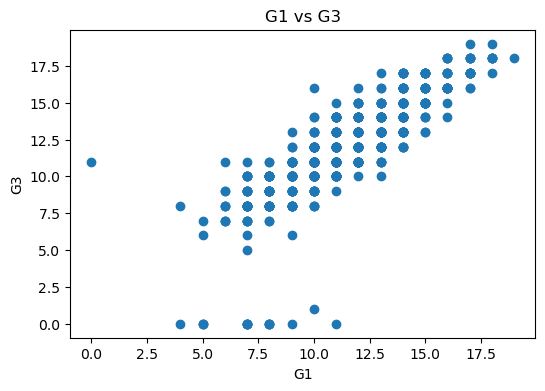

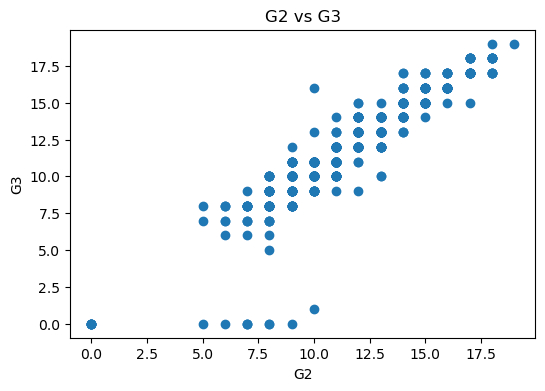

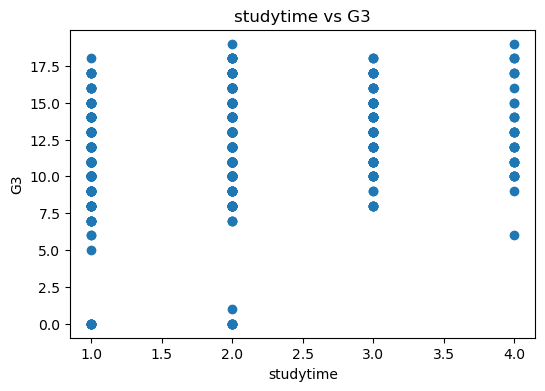

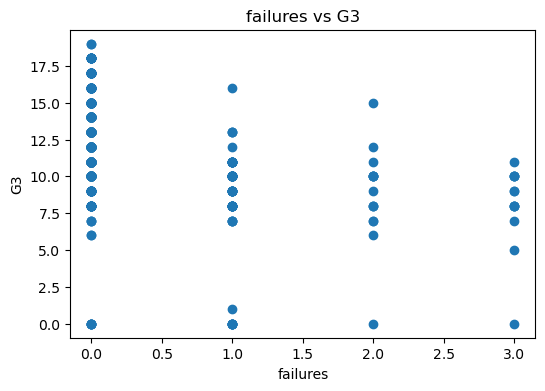

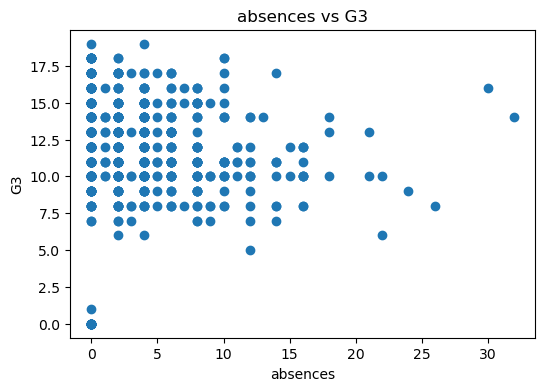

In [12]:
important_features = ["G1","G2","studytime","failures","absences"]

for feature in important_features:

    plt.figure(figsize=(6,4))

    plt.scatter(df[feature], df["G3"])

    plt.xlabel(feature)

    plt.ylabel("G3")

    plt.title(f"{feature} vs G3")

    plt.show()

# Outlier Detection

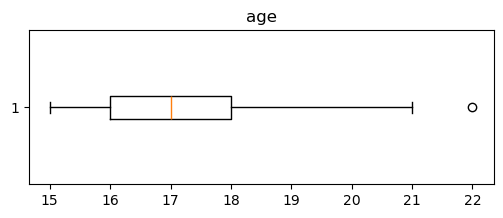

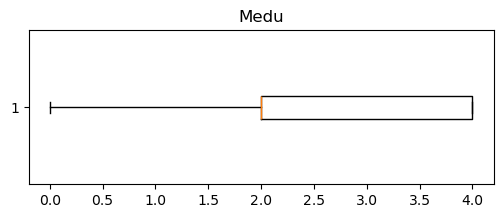

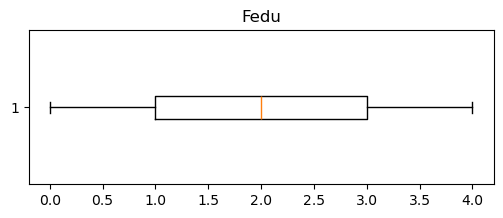

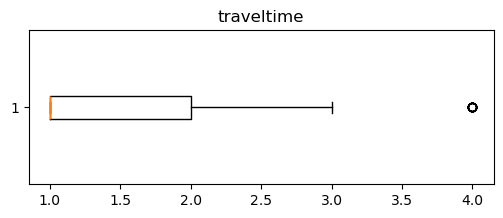

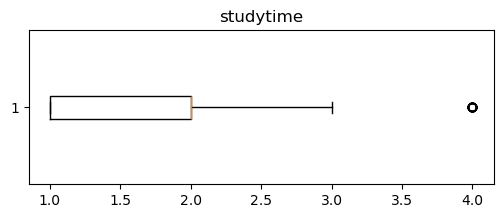

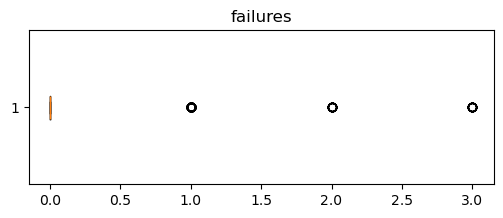

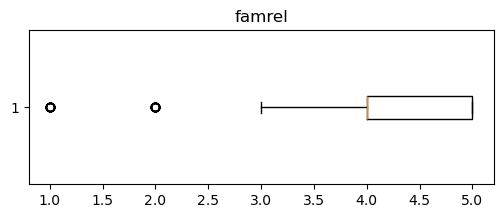

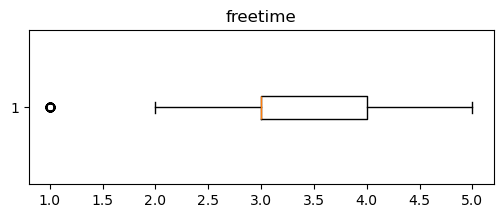

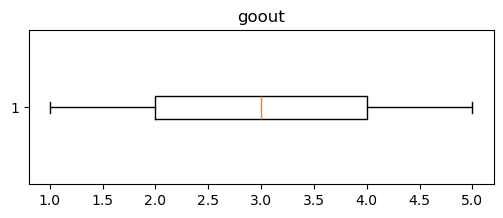

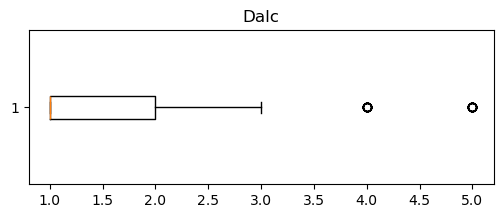

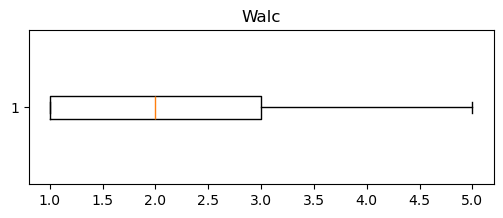

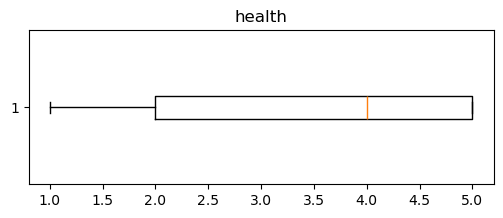

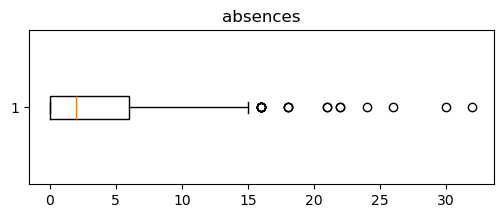

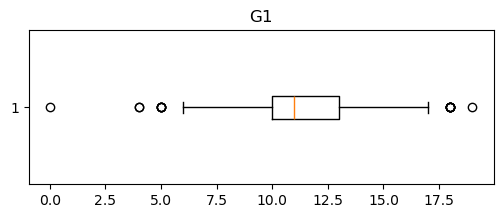

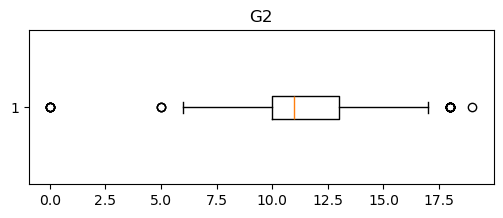

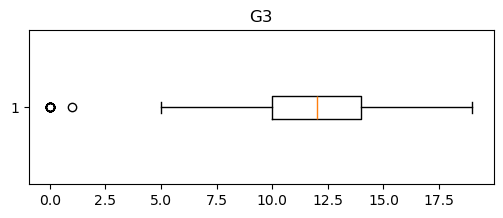

In [14]:
for column in numerical_cols:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

# Summary Statistics

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


# Key Insights

After performing exploratory analysis we observed:

- No missing values.
- No duplicate records.
- Both numerical and categorical variables are present.
- G3 is the prediction target.
- Some numerical variables show stronger relationships with G3.
- Outliers exist in several features.
- Categorical variables will require encoding.
- Numerical variables may require scaling.

# Next Notebook

Notebook 03

Data Preprocessing

We will prepare the dataset for neural network training by:

- Encoding
- Scaling
- Train-Test Split
- Saving processed data